# Boosting: combinar modelos débiles en secuencia

> Cómo AdaBoost y Gradient Boosting construyen un modelo potente sumando árboles pequeños de uno en uno, cada uno centrado en lo que los anteriores hacen mal; qué papel juegan la tasa de aprendizaje y el número de árboles, cómo parar a tiempo (*early stopping*) y por qué es más sensible al ruido en las etiquetas que un Random Forest.
>
> **Requisitos previos:** [Árboles de decisión](08-arboles-decision.ipynb) · [Bagging y Random Forest](10-bagging-y-random-forest.ipynb) · **Relacionado:** [Flujo de ML y evaluación](01-flujo-ml-y-evaluacion.ipynb) · [stacking y cascading](12-stacking-y-cascading.ipynb) · [interpretabilidad](14-interpretabilidad.ipynb)

## 1. Idea clave

El [bagging](10-bagging-y-random-forest.ipynb) promedia en paralelo muchos árboles profundos para reducir la **varianza**. El **boosting** (*potenciación*) hace lo contrario: parte de modelos **débiles** (árboles de una o pocas divisiones, apenas mejores que el azar, con mucho **sesgo**) y los entrena **en secuencia**, de modo que cada uno se concentra en lo que el conjunto anterior todavía hace mal. La suma de todos reduce el sesgo hasta dar un modelo muy flexible.

Hay dos versiones clásicas: **AdaBoost**, que da más peso a los ejemplos mal clasificados, y **Gradient Boosting**, que ajusta cada árbol nuevo a los errores (el gradiente de la pérdida) del modelo acumulado. Es la técnica que suele dar la mejor precisión en datos tabulares, pero a cambio exige más cuidado que un Random Forest: **sí puede sobreajustar** si se añaden demasiados árboles, depende de la tasa de aprendizaje, se entrena en secuencia (no se paraleliza entre árboles) y es sensible al ruido en las etiquetas.

## 2. Conceptos importantes

### 2.1. Intuición: repasar solo lo que falla

Imagina un estudiante que hace un simulacro, anota las preguntas que ha fallado y dedica el siguiente repaso casi solo a ellas; luego hace otro simulacro y repite. Cada repaso es sencillo (un "modelo débil"), pero la secuencia acaba cubriendo casi todo. Eso es el boosting: cada modelo corrige a los anteriores en lugar de trabajar a su lado, como en el bagging.

| | Bagging / Random Forest | Boosting |
|---|---|---|
| Modelos base | Fuertes (árboles profundos), alta varianza | Débiles (árboles pequeños), alto sesgo |
| Cómo se entrenan | En paralelo, independientes | En secuencia, cada uno depende del anterior |
| Qué reduce | Varianza | Sesgo (y, con regularización, algo de varianza) |
| Más modelos | Satura, no sobreajusta | Acaba **sobreajustando** |

Un **modelo débil** (*weak learner*) es el que acierta algo más que el azar. El más pequeño posible con árboles es el *stump*: un árbol de profundidad 1, una sola pregunta.

### 2.2. AdaBoost

AdaBoost (*Adaptive Boosting*) trabaja con **pesos sobre los ejemplos**. Para clasificación binaria con etiquetas $y_i \in \{-1, +1\}$ y $n$ ejemplos:

1. Se inicializan los pesos $w_i = 1/n$.
2. Para $t = 1, \dots, T$:
   - Se entrena un modelo débil $f_t$ con los ejemplos ponderados por $w_i$.
   - Se calcula su **error ponderado** $\varepsilon_t = \sum_{i} w_i \, \mathbb{1}[f_t(x_i) \neq y_i]$ (con los pesos normalizados, $\sum_i w_i = 1$).
   - Se calcula su **voz** en el voto final: $\displaystyle \alpha_t = \tfrac{1}{2} \ln \frac{1 - \varepsilon_t}{\varepsilon_t}$.
   - Se actualizan los pesos: $w_i \leftarrow w_i \, e^{-\alpha_t \, y_i f_t(x_i)}$ y se renormalizan para que sumen 1.
3. La predicción es el voto ponderado: $\displaystyle \hat y(x) = \operatorname{signo}\Big(\sum_{t=1}^{T} \alpha_t f_t(x)\Big)$.

Leído en palabras: si $f_t$ acierta un ejemplo ($y_i f_t(x_i) = +1$), su peso se multiplica por $e^{-\alpha_t} < 1$ y baja; si falla ($-1$), se multiplica por $e^{\alpha_t} > 1$ y sube. Un modelo con $\varepsilon_t < 0{,}5$ tiene $\alpha_t > 0$ y el modelo débil con $\varepsilon_t = 0{,}5$ (azar) no tiene voz ($\alpha_t = 0$). Por eso el siguiente modelo "ve" un problema donde los ejemplos difíciles pesan más.

scikit-learn implementa la variante multiclase **SAMME**, con $\alpha_t = \ln\frac{1-\varepsilon_t}{\varepsilon_t} + \ln(K-1)$ para $K$ clases (multiplicado por `learning_rate`). Con dos clases es el doble que la fórmula anterior, lo que no cambia el signo del voto. Los valores de $\alpha_t$ que verás en 3.2 son los de scikit-learn.

### 2.3. Gradient Boosting

Gradient Boosting (Friedman, 2001) formula el boosting como **descenso de gradiente, pero en el espacio de funciones**. Se construye un modelo aditivo

$$
F_t(x) = F_{t-1}(x) + \eta \, h_t(x)
$$

donde $h_t$ es un árbol pequeño y $\eta \in (0, 1]$ es la **tasa de aprendizaje** (*learning rate* o *shrinkage*). Dada una función de pérdida $L(y, F)$:

1. Se parte de $F_0$ = la constante que minimiza la pérdida (la media de $y$ para el error cuadrático).
2. En cada iteración $t$ se calculan los **pseudorresiduos**, el gradiente negativo de la pérdida respecto a la predicción actual:
$$
r_{ti} = - \left. \frac{\partial L(y_i, F)}{\partial F} \right|_{F = F_{t-1}(x_i)}
$$
3. Se ajusta un árbol pequeño $h_t$ para **predecir $r_{ti}$** a partir de $x_i$ y se suma al modelo con el paso $\eta$.

Dos casos concretos:

- **Regresión con error cuadrático**, $L = \tfrac{1}{2}(y - F)^2$: el pseudorresiduo es el residuo ordinario $r_{ti} = y_i - F_{t-1}(x_i)$. Cada árbol aprende "lo que le falta" a la predicción actual.
- **Clasificación binaria con log-pérdida**: $F$ es el logaritmo de las *odds* y la probabilidad es $p = 1/(1 + e^{-F})$. El pseudorresiduo es $r_{ti} = y_i - p_i$, con $y_i \in \{0, 1\}$: la diferencia entre la etiqueta y la probabilidad actual.

(Friedman además reajusta el valor de cada hoja para minimizar la pérdida; scikit-learn lo hace.) AdaBoost es en realidad un caso de este esquema con la **pérdida exponencial** $L = e^{-yF}$.

### 2.4. Sesgo, varianza y regularización

Cada iteración reduce el error de entrenamiento; con árboles lo bastante flexibles, acaba en cero. A diferencia del bagging, **añadir más árboles sí sobreajusta** (se verá en 3.4). Por eso el boosting se regulariza con varios mandos:

- **Tasa de aprendizaje $\eta$** (*shrinkage*): cada árbol aporta solo una fracción. Con $\eta$ pequeña se avanza despacio y hacen falta más árboles, pero el resultado suele generalizar mejor. $\eta$ y $T$ están **acoplados**: $\eta$ baja pide $T$ alto.
- **Tamaño de los árboles** (`max_depth`, `min_samples_leaf`): controla el orden de las interacciones que puede captar cada término de la suma.
- **Submuestreo** (`subsample` < 1): cada árbol se entrena con una fracción de las filas, tomada sin reemplazo (*stochastic gradient boosting*). Añade azar, como el bagging, y reduce la varianza.
- **Parada temprana** (*early stopping*): se reserva una parte del entrenamiento como validación y se detiene el proceso cuando el error en ella deja de mejorar. Es la forma práctica de elegir $T$.

## 3. Código

Usamos **breast cancer** (569 tumores, 30 medidas numéricas, clase maligno/benigno; `load_breast_cancer`, derivado del repositorio UCI) como en los [árboles](08-arboles-decision.ipynb) y en [Random Forest](10-bagging-y-random-forest.ipynb), para poder comparar. Además: una curva **sintética** en una dimensión para ver el algoritmo paso a paso, un conjunto **sintético con etiquetas ruidosas** (`make_classification`) donde se aprecia el sobreajuste, y `load_diabetes` (442 pacientes, regresión).

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_diabetes, make_classification
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor)
from sklearn.metrics import log_loss
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

### 3.1. Gradient Boosting a mano (regresión)

Una curva $y = \sin(x)$ con ruido, 150 puntos. Siguiendo 2.3 con error cuadrático: empezamos con la media, y en cada iteración ajustamos un árbol de profundidad 2 a los residuos y lo sumamos con $\eta = 0{,}3$. Dibujamos el modelo tras 1, 5, 20 y 100 árboles.

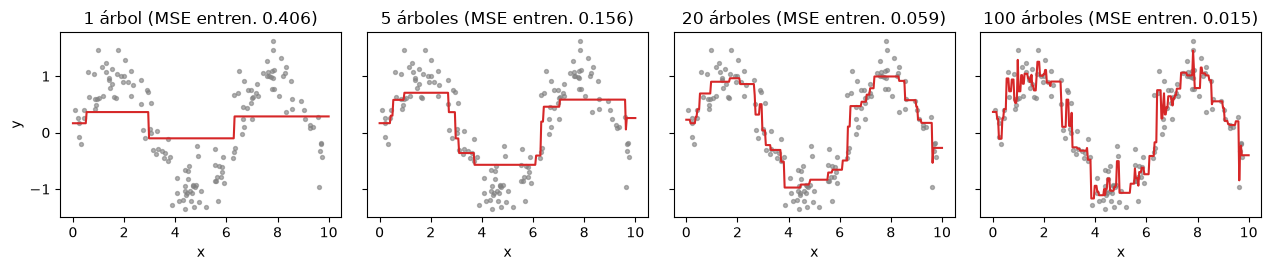

MSE de entrenamiento: solo la media 0.632 | 100 árboles 0.015 | varianza real del ruido 0.090


In [2]:
rng_toy = np.random.default_rng(42)
x_toy = np.sort(rng_toy.uniform(0, 10, 150))
y_toy = np.sin(x_toy) + 0.3 * rng_toy.normal(size=150)  # ruido con desviación 0,3 (varianza 0,09)
X_toy = x_toy.reshape(-1, 1)
malla = np.linspace(0, 10, 300).reshape(-1, 1)

eta = 0.3
F_toy = np.full_like(y_toy, y_toy.mean())     # F_0: la media
F_malla = np.full(len(malla), y_toy.mean())
curvas, mse = {}, {0: np.mean((y_toy - F_toy) ** 2)}
for t in range(1, 101):
    arbol = DecisionTreeRegressor(max_depth=2, random_state=42).fit(X_toy, y_toy - F_toy)  # ajusta los residuos
    F_toy += eta * arbol.predict(X_toy)
    F_malla += eta * arbol.predict(malla)
    if t in (1, 5, 20, 100):
        curvas[t], mse[t] = F_malla.copy(), np.mean((y_toy - F_toy) ** 2)

fig, ejes = plt.subplots(1, 4, figsize=(13, 2.8), sharey=True)
for eje, (t, curva) in zip(ejes, curvas.items()):
    eje.scatter(x_toy, y_toy, s=8, color="gray", alpha=0.6)
    eje.plot(malla, curva, color="tab:red")
    eje.set_title(f"{t} árbol{'es' if t > 1 else ''} (MSE entren. {mse[t]:.3f})")
    eje.set_xlabel("x")
ejes[0].set_ylabel("y")
plt.tight_layout()
plt.show()
print(f"MSE de entrenamiento: solo la media {mse[0]:.3f} | 100 árboles {mse[100]:.3f} | varianza real del ruido 0.090")

Con un solo árbol de profundidad 2 el modelo ya es una escalera de 4 tramos y el MSE baja de 0,632 (solo la media) a 0,406; con 5 árboles aparece la forma de la onda (0,156), con 20 sigue de cerca la curva (0,059) y con 100 pasa **por debajo de la varianza del ruido** (0,015 frente a 0,090): ya no solo aprende la señal, sino que **memoriza el ruido**. El error de entrenamiento siempre baja; lo que importa es el error en datos nuevos, y para eso hace falta validación (3.4).

### 3.2. AdaBoost

`AdaBoostClassifier` usa *stumps* por defecto. Entrenamos 200 y miramos el error ponderado $\varepsilon_t$ y la voz $\alpha_t$ de los primeros y últimos modelos. Separamos un 20 % para test y usamos validación cruzada estratificada en el entrenamiento (clase 0 = maligno, 1 = benigno).

In [3]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ada = AdaBoostClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)
pesos = pd.DataFrame({"error ponderado": ada.estimator_errors_, "voz (alfa)": ada.estimator_weights_})
pesos.index = pesos.index + 1
pesos.index.name = "modelo t"
pesos.loc[[1, 2, 3, 4, 5, 100, 200]].round(3).T

modelo t,1,2,3,4,5,100,200
error ponderado,0.077,0.149,0.141,0.217,0.273,0.333,0.340
voz (alfa),2.485,1.744,1.807,1.285,0.979,0.697,0.665


El primer *stump* tiene un error de solo 0,077 y por eso una voz grande ($\alpha_1 = 2{,}49$). A partir de ahí el error ponderado **sube** (0,15, 0,14, 0,22…) y la voz baja: los pesos se han desplazado hacia los ejemplos difíciles, así que cada nuevo *stump* se enfrenta a un problema más duro que el anterior. Hacia el final los errores rondan 0,33–0,34 y las voces son pequeñas (≈ 0,7) pero positivas, porque cada modelo sigue siendo mejor que el azar ($\varepsilon_t < 0{,}5$).

### 3.3. Árbol, Random Forest y boosting

Comparamos en validación cruzada y en test un *stump*, un árbol sin límites, un Random Forest y tres versiones de boosting: AdaBoost, `GradientBoostingClassifier` y `HistGradientBoostingClassifier` (variante basada en histogramas, mucho más rápida con muchas filas; ver sección 5).

In [4]:
modelos = {
    "Stump (profundidad 1)": DecisionTreeClassifier(max_depth=1, random_state=42),
    "Árbol": DecisionTreeClassifier(random_state=42),
    "Random Forest (300)": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "AdaBoost (200 stumps)": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting (100 árboles)": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
}
filas = {}
for nombre, modelo in modelos.items():
    puntuaciones = cross_val_score(modelo, X_train, y_train, cv=cv)
    filas[nombre] = {"CV media": puntuaciones.mean(), "CV std": puntuaciones.std(),
                     "test": modelo.fit(X_train, y_train).score(X_test, y_test)}
pd.DataFrame(filas).T.round(3)

,CV media,CV std,test
Stump (profundidad 1),0.903,0.008,0.921
Árbol,0.916,0.018,0.912
Random Forest (300),0.965,0.018,0.947
AdaBoost (200 stumps),0.976,0.016,0.965
Gradient Boosting (100 árboles),0.952,0.015,0.956
HistGradientBoosting,0.963,0.015,0.956


Un *stump* solo acierta el 90,3 % y un árbol profundo el 91,6 %; **AdaBoost con 200 de esos mismos *stumps* llega al 97,6 %**: sumar modelos débiles en secuencia da un modelo fuerte. Pero entre Random Forest (0,965), AdaBoost (0,976), Gradient Boosting (0,952) e HistGradientBoosting (0,963) las diferencias (≈ 2 puntos) están dentro de la desviación entre particiones (≈ 0,015–0,018), y con 114 casos de test un ejemplo mueve la exactitud 0,009. En un conjunto tan limpio y pequeño **el boosting no se distingue de un buen Random Forest**; su ventaja aparece con más datos, relaciones complejas y ajuste cuidadoso.

### 3.4. Tasa de aprendizaje, número de árboles y sobreajuste

Aquí sí se ve el sobreajuste. Usamos un conjunto sintético con un 10 % de etiquetas cambiadas al azar (ruido) y entrenamos 500 árboles de profundidad 3 con tres tasas de aprendizaje. `staged_predict_proba` devuelve las probabilidades tras cada iteración, de modo que podemos calcular la **log-pérdida en test** árbol a árbol sin reentrenar (la log-pérdida penaliza más la confianza equivocada que la exactitud y revela antes el sobreajuste).

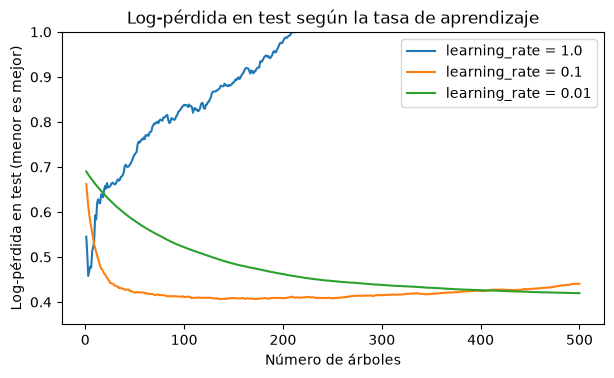

,mínimo en test,en el árbol nº,test con 500 árboles,entrenamiento con 500
learning_rate = 1.0,0.458,3,1.625,0.000
learning_rate = 0.1,0.406,171,0.441,0.048
learning_rate = 0.01,0.420,500,0.420,0.317


In [5]:
X_rui, y_rui = make_classification(n_samples=2000, n_features=20, n_informative=5, n_redundant=2,
                                   flip_y=0.1, class_sep=0.8, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_rui, y_rui, test_size=0.4, stratify=y_rui, random_state=42)

filas = {}
plt.figure(figsize=(7, 3.8))
for lr in [1.0, 0.1, 0.01]:
    gb = GradientBoostingClassifier(n_estimators=500, learning_rate=lr, max_depth=3, random_state=42).fit(Xr_train, yr_train)
    perdida_test = [log_loss(yr_test, p) for p in gb.staged_predict_proba(Xr_test)]
    perdida_train = [log_loss(yr_train, p) for p in gb.staged_predict_proba(Xr_train)]
    plt.plot(range(1, 501), perdida_test, label=f"learning_rate = {lr}")
    filas[f"learning_rate = {lr}"] = {"mínimo en test": min(perdida_test), "en el árbol nº": int(np.argmin(perdida_test)) + 1,
                                      "test con 500 árboles": perdida_test[-1], "entrenamiento con 500": perdida_train[-1]}
plt.ylim(0.35, 1.0)
plt.title("Log-pérdida en test según la tasa de aprendizaje")
plt.xlabel("Número de árboles")
plt.ylabel("Log-pérdida en test (menor es mejor)")
plt.legend()
plt.show()
pd.DataFrame.from_dict(filas, orient="index").round(3)

Con `learning_rate = 1` el modelo toca fondo con **solo 3 árboles** (0,458) y luego empeora sin parar: con 500 árboles la pérdida en test es 1,625 mientras la de entrenamiento es 0,000, memoriza el ruido y está muy seguro de predicciones equivocadas (el eje del gráfico está recortado en 1,0). Con `0.1` el mínimo es mejor (0,406) y llega en el árbol 171, y después sube de forma suave (0,441 con 500). Con `0.01` aún no ha llegado al mínimo con 500 árboles (0,420 y bajando, sin igualar todavía el 0,406 de `0.1`): **tasa baja = más árboles**, pero la curva es más estable y menos sensible a pasarse de árboles.

### 3.5. Parada temprana (*early stopping*)

En lugar de elegir $T$ a ojo, fijamos un máximo muy alto (2000) y dejamos que scikit-learn pare solo: reserva el 20 % del entrenamiento como validación y se detiene cuando 10 iteraciones seguidas no mejoran. El test queda intacto para la evaluación final.

In [6]:
gb_parada = GradientBoostingClassifier(n_estimators=2000, learning_rate=0.1, max_depth=3, n_iter_no_change=10,
                                       validation_fraction=0.2, random_state=42).fit(Xr_train, yr_train)
gb_500 = GradientBoostingClassifier(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42).fit(Xr_train, yr_train)
pd.DataFrame({"árboles entrenados": [gb_parada.n_estimators_, gb_500.n_estimators_],
              "exactitud en test": [gb_parada.score(Xr_test, yr_test), gb_500.score(Xr_test, yr_test)]},
             index=["con parada temprana (máx. 2000)", "sin parada (500)"]).round(3)

,árboles entrenados,exactitud en test
con parada temprana (máx. 2000),76,0.828
sin parada (500),500,0.826


La parada temprana se detiene en **76 árboles** y acierta lo mismo en test (0,828 frente a 0,826 con 500): el modelo tiene 6,6 veces menos árboles y es más rápido de entrenar, y no hemos tenido que adivinar $T$. Con $\eta$ fija y baja, la parada temprana es la forma más barata de ajustar el número de árboles.

### 3.6. Regresión

`GradientBoostingRegressor` suma árboles a los residuos, como en 3.1. Lo comparamos con un Random Forest en `load_diabetes` ($R^2$ en validación cruzada), con los parámetros por defecto y con una configuración más regularizada elegida de antemano (árboles de profundidad 2, `learning_rate=0.05`, 300 árboles, `subsample=0.5`), sin búsqueda.

In [7]:
X_dia, y_dia = load_diabetes(return_X_y=True, as_frame=True)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
regresores = {
    "Random Forest (300)": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting (por defecto)": GradientBoostingRegressor(random_state=42),
    "Gradient Boosting regularizado": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=2,
                                                                subsample=0.5, random_state=42),
}
filas = {}
for nombre, modelo in regresores.items():
    r2 = cross_val_score(modelo, X_dia, y_dia, cv=kf, scoring="r2")
    filas[nombre] = {"R² CV media": r2.mean(), "R² CV std": r2.std()}
pd.DataFrame(filas).T.round(3)

,R² CV media,R² CV std
Random Forest (300),0.427,0.095
Gradient Boosting (por defecto),0.418,0.088
Gradient Boosting regularizado,0.446,0.092


El bosque da $R^2 \approx 0{,}43$ y Gradient Boosting con parámetros por defecto 0,42: **empate**. La versión regularizada (árboles pequeños, `learning_rate` baja, submuestreo) sube a 0,45, pero la mejora (≈ 0,02) es mucho menor que la desviación entre particiones (≈ 0,09), así que con 442 pacientes no se puede afirmar que sea mejor. Lo que sí se aprecia es la dirección: en un problema ruidoso, regularizar el boosting es lo que lo hace competitivo con el bosque.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Consejo |
|---|---|---|
| `n_estimators` | Número de árboles $T$ | A diferencia del bosque, **más no es mejor** (3.4). Mejor fijarlo alto y usar parada temprana (3.5) |
| `learning_rate` | Contribución de cada árbol $\eta$ | Pequeño (≤ 0,1) y más árboles suele generalizar mejor; es el parámetro más acoplado a `n_estimators` |
| `max_depth` | Profundidad de cada árbol | Árboles pequeños, 2–5 en Gradient Boosting (orden de las interacciones) y *stumps* en AdaBoost; hay que ajustarlo, no suponerlo |
| `subsample` | Fracción de filas por árbol | 0,5–0,8 añade azar y reduce la varianza; con 1,0 el proceso es determinista |
| `min_samples_leaf` | Tamaño mínimo de las hojas | Suaviza el modelo y limita la memorización del ruido |
| `max_features` | Variables candidatas por corte | Menos variables decorrela y acelera, como en Random Forest |
| `n_iter_no_change`, `validation_fraction` | Parada temprana | Con `n_iter_no_change` definido, se para tras ese número de iteraciones sin mejora en la validación |
| `loss` | Función de pérdida | `"log_loss"` por defecto en clasificación; `"exponential"` recupera AdaBoost; en regresión, `"huber"` o `"absolute_error"` son más robustas a atípicos |
| `estimator` (AdaBoost) | Modelo débil | *Stump* por defecto; árboles algo más profundos si los datos tienen interacciones |
| `random_state` | Semilla (submuestreo, variables) | Fíjala para reproducir resultados |

### 4.2. Errores comunes

**1. Ajustar `n_estimators` sin tener en cuenta la tasa de aprendizaje.** Como se vio en 3.4, con `learning_rate=1` 3 árboles son el óptimo y 500 son un desastre; con `0.01`, 500 aún se quedan cortos. Los dos parámetros se ajustan **juntos**: fija una tasa baja, pon un máximo alto de árboles y deja que la parada temprana (3.5) decida.

**2. Elegir el número de árboles mirando el test.** Si se escoge el $T$ que mejor puntúa en test, el test deja de ser independiente. Usa la validación interna de la parada temprana o la validación cruzada, y reserva el test para una única evaluación final.

**3. Informar del objeto equivocado.** Cuando se ajustan varios modelos con varias búsquedas, cada una guarda su propio `best_params_` y `best_score_`. Copiar y pegar la celda de un modelo para el siguiente y olvidar cambiar el nombre del objeto produce informes de hiperparámetros que **pertenecen a otro modelo**: una vez reporté para un boosting un `max_depth` de 20 y un `max_features` que en realidad eran los de un Random Forest. Dos defensas: desconfía de valores imposibles (un boosting con árboles de profundidad 20 debería hacer saltar la alarma) y recorre las búsquedas en un bucle en lugar de reescribir el informe.

In [8]:
busquedas = {
    "Random Forest": GridSearchCV(RandomForestClassifier(random_state=42),
                                  {"max_depth": [3, None], "max_features": ["sqrt", 0.5]}, cv=3, scoring="f1_macro", n_jobs=-1),
    "Gradient Boosting": GridSearchCV(GradientBoostingClassifier(random_state=42),
                                      {"learning_rate": [0.05, 0.2], "max_depth": [2, 3]}, cv=3, scoring="f1_macro", n_jobs=-1),
}
for nombre, busqueda in busquedas.items():
    busqueda.fit(X_train, y_train)
    print(f"{nombre}: {busqueda.best_params_} | F1 macro CV {busqueda.best_score_:.3f}")

Random Forest: {'max_depth': None, 'max_features': 0.5} | F1 macro CV 0.953


Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 2} | F1 macro CV 0.958


Cada línea sale de su propio objeto, y los parámetros que aparecen son los de la rejilla de cada modelo: es imposible mezclarlos.

**4. Rejillas enormes y secuenciales.** Una rejilla de 3 × 3 × 3 × 2 valores con validación cruzada de 5 particiones son 270 entrenamientos de un modelo que no se paraleliza entre árboles. Reduce el coste: fija `learning_rate` baja y delega `n_estimators` en la parada temprana, y explora el resto con `RandomizedSearchCV` o una rejilla pequeña. Para conjuntos grandes, usa `HistGradientBoostingClassifier`.

**5. Subestimar el ruido en las etiquetas.** El boosting da más peso a los ejemplos que no consigue ajustar, y los ejemplos con la etiqueta equivocada son justo los más difíciles: acaba dedicando sus árboles a **memorizar errores**. Un Random Forest promedia árboles independientes y lo sufre menos. Lo comprobamos corrompiendo una fracción de las etiquetas de **entrenamiento** (y evaluando sobre test limpio) en un conjunto sin ruido. AdaBoost usa aquí árboles de profundidad 3 como modelo débil.

In [9]:
X_lim, y_lim = make_classification(n_samples=4000, n_features=20, n_informative=5, n_redundant=2,
                                   flip_y=0, class_sep=1.0, random_state=42)
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_lim, y_lim, test_size=0.4, stratify=y_lim, random_state=42)

filas = {}
for fraccion in [0, 0.1, 0.2, 0.3]:
    rng_rui = np.random.default_rng(42)
    y_corrupto = yl_train.copy()
    cambiar = rng_rui.random(len(y_corrupto)) < fraccion
    y_corrupto[cambiar] = 1 - y_corrupto[cambiar]  # etiquetas equivocadas solo en entrenamiento
    modelos_rui = {
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
        "AdaBoost (profundidad 3)": AdaBoostClassifier(DecisionTreeClassifier(max_depth=3), n_estimators=300, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    }
    filas[f"{fraccion:.0%} de etiquetas mal"] = {nombre: m.fit(Xl_train, y_corrupto).score(Xl_test, yl_test)
                                                 for nombre, m in modelos_rui.items()}
pd.DataFrame(filas).T.round(3)

,Random Forest,AdaBoost (profundidad 3),Gradient Boosting
0% de etiquetas mal,0.935,0.954,0.929
10% de etiquetas mal,0.932,0.904,0.904
20% de etiquetas mal,0.911,0.827,0.884
30% de etiquetas mal,0.847,0.732,0.819


Sin ruido, AdaBoost es el mejor (0,954 frente a 0,935 del bosque). Con un 10 % de etiquetas mal el bosque casi no se inmuta (0,932), mientras AdaBoost cae 5 puntos (0,904) y Gradient Boosting, 2,5 (0,904); con un 30 % el bosque pierde 9 puntos y AdaBoost, **22** (0,732). Si sospechas ruido en las etiquetas, revisa los datos antes de ajustar el boosting y usa `subsample`, `learning_rate` baja y hojas grandes; AdaBoost es el más vulnerable de los dos, porque su actualización exponencial de pesos castiga más los errores.

**6. Desbalanceo de clases.** Gradient Boosting minimiza la pérdida global, así que con clases muy desiguales se centra en la mayoritaria y la exactitud engaña. Evalúa con una métrica por clase (sensibilidad, $F_1$ macro) y pondera con `sample_weight` en `fit` (por ejemplo con `sklearn.utils.class_weight.compute_sample_weight("balanced", y)`). El efecto del compromiso entre sensibilidad y precisión se ve con un bosque en [Random Forest](10-bagging-y-random-forest.ipynb) y las técnicas de remuestreo, en [muestreo y desbalanceo](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb).

**7. Preprocesar de más (o fuera de la validación).** Los árboles son invariantes al escalado ([igual que en los árboles](08-arboles-decision.ipynb)), así que estandarizar no aporta nada. Cualquier paso que sí haga falta (imputar, codificar categorías) debe ir dentro de un `Pipeline` para que se ajuste solo con cada partición de entrenamiento; ver el [flujo de ML](01-flujo-ml-y-evaluacion.ipynb).

**8. Esperar que extrapole.** Como cualquier modelo de árboles, no predice fuera del rango visto en entrenamiento; la demostración está en [Random Forest](10-bagging-y-random-forest.ipynb) y se aplica igual aquí.

**9. Fiarse de la importancia por impureza.** Sufre el mismo sesgo hacia variables con muchos valores que en el bosque; calcula la importancia por permutación en test ([interpretabilidad](14-interpretabilidad.ipynb)).

## 5. Comparación con métodos relacionados

| Método | Cómo combina | Reduce | Entrenamiento | Sensible a ruido en etiquetas | Cuándo usarlo |
|---|---|---|---|---|---|
| [Árbol](08-arboles-decision.ipynb) | — (un solo modelo) | — | Rápido | Medio | Cuando hay que explicar con reglas |
| [Random Forest](10-bagging-y-random-forest.ipynb) | Promedio paralelo de árboles profundos | Varianza | Paralelo | Poco | Primera opción robusta, ajuste mínimo, estimación OOB gratis |
| **AdaBoost** | Secuencial: repondera los ejemplos mal clasificados | Sesgo | Secuencial | Mucho | Conjuntos limpios y pequeños, con *stumps*; sirve para entender el boosting |
| **Gradient Boosting** (`GradientBoosting*`) | Secuencial: cada árbol ajusta el gradiente de la pérdida | Sesgo (y varianza con `subsample`) | Secuencial, lento con muchas filas | Algo | Máxima precisión tabular, con tasa baja y parada temprana |
| **Histogram GB** (`HistGradientBoosting*`) | Igual, con variables discretizadas en histogramas | Sesgo | Mucho más rápido con > 10 000 filas | Algo | Opción por defecto de boosting en scikit-learn: valores ausentes y categóricas de forma nativa, parada temprana automática con muchas filas |
| XGBoost, LightGBM, CatBoost | Variantes de Gradient Boosting con regularización explícita y optimizaciones de velocidad | Sesgo | Muy rápido, con GPU | Algo | Bibliotecas externas muy extendidas en problemas tabulares grandes; no se usan en este notebook |
| [Stacking](12-stacking-y-cascading.ipynb) | Un metamodelo combina modelos de naturaleza distinta | Sesgo y varianza | Varias fases | Depende de la base | Cuando hay modelos diversos y complementarios |

**Cuándo elegir boosting.** Cuando importa exprimir la precisión en datos tabulares, hay suficientes datos y tiempo para ajustar la tasa de aprendizaje, la profundidad y la parada temprana, y las etiquetas son fiables. Si se quiere un modelo sólido sin apenas ajuste, o hay mucho ruido en las etiquetas, un [Random Forest](10-bagging-y-random-forest.ipynb) suele ser más seguro; con más de unas decenas de miles de filas, prefiere `HistGradientBoosting`.

## 6. Referencias

### Fuentes

- scikit-learn: [*Ensembles: Gradient boosting, random forests, bagging, voting, stacking*](https://scikit-learn.org/stable/modules/ensemble.html) (AdaBoost, Gradient Boosting, `HistGradientBoosting`, *shrinkage*, submuestreo y parada temprana).
- scikit-learn: [`AdaBoostClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html), [`GradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html), [`GradientBoostingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html), [`HistGradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) y [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).
- scikit-learn: [`log_loss`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html) y [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- scikit-learn: [`load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html), [`load_diabetes`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) y [`make_classification`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html).
- UCI Machine Learning Repository: [*Breast Cancer Wisconsin (Diagnostic)*](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), origen del conjunto de datos.

### Para saber más

- Freund, Y. y Schapire, R. E. (1997). *A decision-theoretic generalization of on-line learning and an application to boosting*. Journal of Computer and System Sciences, 55(1), 119–139. [doi:10.1006/jcss.1997.1504](https://doi.org/10.1006/jcss.1997.1504). El artículo que presenta AdaBoost, con la actualización de pesos y las garantías sobre el error de entrenamiento.
- Friedman, J. H. (2001). *Greedy function approximation: A gradient boosting machine*. The Annals of Statistics, 29(5), 1189–1232. [doi:10.1214/aos/1013203451](https://doi.org/10.1214/aos/1013203451). El artículo que formula el boosting como descenso de gradiente en el espacio de funciones, con el *shrinkage* y el submuestreo estocástico.